In [ ]:
# התקנת ספריות
!pip install -q torch torchaudio transformers tqdm scikit-learn pandas matplotlib seaborn

# Imports
import os
import json
import random
import numpy as np
import pandas as pd

import torch
import torchaudio

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW

from transformers import WavLMForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset from Google Drive to local storage...")

if not os.path.exists("/content/dataset_split"):
    !cp -r "/content/drive/MyDrive/dataset_split" "/content/"
    print("Dataset copied successfully!")
else:
    print("Dataset already exists in /content/dataset_split")

# ==========================================
# CONFIG
# ==========================================

CONFIG = {
    # שם הניסוי
    "experiment_name": "wavlm_exp_001",

    # Reproducibility
    "seed": 42,

    # Audio
    "target_sample_rate": 16000,
    "max_duration": 4,

    # Training
    "batch_size": 4,
    "epochs": 5,
    "learning_rate": 1e-5,

    # Split
    "val_ratio": 0.15,

    # Model
    "model_name": "microsoft/wavlm-base",

    # Freeze options
    "freeze_feature_extractor": True,
    "freeze_encoder": False,

    # Paths
    "train_dir": "/content/dataset_split/train",
    "test_dir": "/content/dataset_split/test",

    # Results
    "results_dir": "/content/results"
}

# ==========================================
# Seeds
# ==========================================

SEED = CONFIG["seed"]

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ==========================================
# Derived values
# ==========================================

TARGET_SAMPLE_RATE = CONFIG["target_sample_rate"]
MAX_DURATION = CONFIG["max_duration"]

MAX_LENGTH = TARGET_SAMPLE_RATE * MAX_DURATION

BATCH_SIZE = CONFIG["batch_size"]
EPOCHS = CONFIG["epochs"]
LR = CONFIG["learning_rate"]

VAL_RATIO = CONFIG["val_ratio"]

TRAIN_DIR = CONFIG["train_dir"]
TEST_DIR = CONFIG["test_dir"]

# ==========================================
# Results folders
# ==========================================

EXPERIMENT_DIR = os.path.join(
    CONFIG["results_dir"],
    CONFIG["experiment_name"]
)

os.makedirs(EXPERIMENT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    EXPERIMENT_DIR,
    "best_model.pt"
)

# ==========================================
# Device
# ==========================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"Using device: {device}")
print(f"Experiment: {CONFIG['experiment_name']}")
print(f"Results folder: {EXPERIMENT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Experiment: wavlm_exp_001
Results folder: /content/results/wavlm_exp_001


In [ ]:
# ==========================================
# 1. Dataset ששומר גם את סוג ההתקפה
# ==========================================

class DeepfakeAudioDataset(Dataset):
    def __init__(self, root_dir, target_sample_rate=16000, max_duration=4, mode='train'):
        self.samples = []
        self.target_sample_rate = target_sample_rate
        self.max_length = target_sample_rate * max_duration
        self.mode = mode
        self.valid_exts = ('.wav', '.mp3', '.flac', '.m4a')

        # real = 0
        real_dir = os.path.join(root_dir, 'real')
        if os.path.exists(real_dir):
            for file in os.listdir(real_dir):
                if file.lower().endswith(self.valid_exts):
                    self.samples.append({
                        "path": os.path.join(real_dir, file),
                        "label": 0,
                        "attack_type": "real"
                    })

        # fake = 1
        fake_dir = os.path.join(root_dir, 'fake')
        if os.path.exists(fake_dir):
            for attack_folder in os.listdir(fake_dir):
                attack_path = os.path.join(fake_dir, attack_folder)

                if os.path.isdir(attack_path):
                    for subdir, _, files in os.walk(attack_path):
                        for file in files:
                            if file.lower().endswith(self.valid_exts):
                                self.samples.append({
                                    "path": os.path.join(subdir, file),
                                    "label": 1,
                                    "attack_type": attack_folder
                                })

        self.filepaths = [s["path"] for s in self.samples]
        self.labels = [s["label"] for s in self.samples]
        self.attack_types = [s["attack_type"] for s in self.samples]

        print(f"[{mode}] Loaded {len(self.samples)} files from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def _load_audio(self, filepath):
        waveform, sample_rate = torchaudio.load(filepath)

        # המרה למונו אם יש יותר מערוץ אחד
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # התאמת קצב דגימה ל-16kHz
        if sample_rate != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=self.target_sample_rate
            )
            waveform = resampler(waveform)

        return waveform.squeeze(0)

    def _crop_or_pad(self, waveform):
        length = waveform.shape[0]

        # אם האודיו ארוך מדי
        if length > self.max_length:
            if self.mode == 'train':
                # באימון: חיתוך אקראי כדי להגדיל גיוון
                start = random.randint(0, length - self.max_length)
            else:
                # ב-validation/test: חיתוך מהאמצע לצורך יציבות
                start = (length - self.max_length) // 2

            waveform = waveform[start:start + self.max_length]
            attention_mask = torch.ones(self.max_length, dtype=torch.long)

        # אם האודיו קצר מדי
        else:
            pad_length = self.max_length - length
            waveform = torch.nn.functional.pad(waveform, (0, pad_length))

            attention_mask = torch.cat([
                torch.ones(length, dtype=torch.long),
                torch.zeros(pad_length, dtype=torch.long)
            ])

        return waveform, attention_mask

    def __getitem__(self, idx):
        sample = self.samples[idx]

        waveform = self._load_audio(sample["path"])
        waveform, attention_mask = self._crop_or_pad(waveform)

        return {
            "input_values": waveform,
            "attention_mask": attention_mask,
            "labels": torch.tensor(sample["label"], dtype=torch.long),

            # חשוב לדוחות בהמשך
            "path": sample["path"],
            "attack_type": sample["attack_type"]
        }

In [ ]:
# ==========================================
# 2. פונקציה לפיצול מאוזן לפי תיקיות התקיפה
# ==========================================
def stratified_split_by_attack(dataset, val_ratio=0.15, seed=42):
    random.seed(seed)

    group_to_indices = {}

    for idx, attack_type in enumerate(dataset.attack_types):
        if attack_type not in group_to_indices:
            group_to_indices[attack_type] = []
        group_to_indices[attack_type].append(idx)

    train_indices = []
    val_indices = []

    print("Split summary by class/attack type:")
    print("-" * 50)

    for group_name, indices in group_to_indices.items():
        random.shuffle(indices)

        n_val = max(1, int(len(indices) * val_ratio)) if len(indices) > 1 else 0

        val_group = indices[:n_val]
        train_group = indices[n_val:]

        # אם בגלל גודל קטן הכל נכנס ל-val, נשאיר לפחות דגימה אחת ל-train
        if len(train_group) == 0 and len(val_group) > 0:
            train_group = [val_group.pop()]

        train_indices.extend(train_group)
        val_indices.extend(val_group)

        print(f"{group_name:35s} train={len(train_group):4d} | val={len(val_group):4d} | total={len(indices):4d}")

    random.shuffle(train_indices)
    random.shuffle(val_indices)

    return train_indices, val_indices

In [ ]:
# ==========================================
# 3. יצירת datasets
# ==========================================

full_train_dataset_for_train = DeepfakeAudioDataset(
    root_dir=TRAIN_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    max_duration=MAX_DURATION,
    mode='train'
)

full_train_dataset_for_val = DeepfakeAudioDataset(
    root_dir=TRAIN_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    max_duration=MAX_DURATION,
    mode='val'
)

test_dataset = DeepfakeAudioDataset(
    root_dir=TEST_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    max_duration=MAX_DURATION,
    mode='test'
)

# ==========================================
# Train / Validation Split
# ==========================================

train_indices, val_indices = stratified_split_by_attack(
    full_train_dataset_for_train,
    val_ratio=VAL_RATIO,
    seed=SEED
)

train_dataset = Subset(
    full_train_dataset_for_train,
    train_indices
)

val_dataset = Subset(
    full_train_dataset_for_val,
    val_indices
)

# ==========================================
# Dataset Summary
# ==========================================

print("full_train_dataset_for_train:", len(full_train_dataset_for_train))
print("full_train_dataset_for_val:", len(full_train_dataset_for_val))
print("test_dataset:", len(test_dataset))

print("train_indices:", len(train_indices))
print("val_indices:", len(val_indices))

# ==========================================
# DataLoaders
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset sizes:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

[train] Loaded 10625 files from /content/drive/MyDrive/dataset_split/train
[val] Loaded 10625 files from /content/drive/MyDrive/dataset_split/train
[test] Loaded 2661 files from /content/drive/MyDrive/dataset_split/test
Split summary by class/attack type:
--------------------------------------------------
real                                train=4517 | val= 797 | total=5314
unknown                             train= 753 | val= 132 | total= 885
waveform_concatenation              train= 753 | val= 132 | total= 885
neural_vocoder_nonautoregressive    train= 753 | val= 132 | total= 885
neural_vocoder_autoregressive       train= 753 | val= 132 | total= 885
traditional_vocoder                 train= 753 | val= 132 | total= 885
elevenlabs_fake                     train= 754 | val= 132 | total= 886
full_train_dataset_for_train: 10625
full_train_dataset_for_val: 10625
test_dataset: 2661
train_indices: 9036
val_indices: 1589

Dataset sizes:
Train samples: 9036
Val samples:   1589
Test samples:

In [ ]:
print("\nAttack types in train set:")
print(full_train_dataset_for_train.attack_types[:10])

print("\nUnique attack types:")
print(sorted(set(full_train_dataset_for_train.attack_types)))

In [ ]:
# ==========================================
# 4. טעינת מודל WavLM
# ==========================================

model = WavLMForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=2
)

# ==========================================
# Freeze Feature Extractor
# ==========================================

if CONFIG["freeze_feature_extractor"]:
    print("Freezing feature extractor...")
    model.wavlm.feature_extractor._freeze_parameters()

# ==========================================
# Freeze Encoder
# ==========================================

if CONFIG["freeze_encoder"]:
    print("Freezing WavLM encoder...")

    for param in model.wavlm.encoder.parameters():
        param.requires_grad = False

model = model.to(device)

# ==========================================
# Optimizer
# ==========================================

trainable_params = filter(
    lambda p: p.requires_grad,
    model.parameters()
)

optimizer = AdamW(
    trainable_params,
    lr=LR,
    weight_decay=0.01
)

print("\nModel loaded successfully")
print("Model:", CONFIG["model_name"])
print("Learning Rate:", LR)
print("Freeze Feature Extractor:", CONFIG["freeze_feature_extractor"])
print("Freeze Encoder:", CONFIG["freeze_encoder"])

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 
projector.bias    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing feature extractor...

Model loaded successfully
Model: microsoft/wavlm-base
Learning Rate: 1e-05
Freeze Feature Extractor: True
Freeze Encoder: False

Total Parameters: 94,579,314
Trainable Parameters: 90,378,866


In [ ]:
# ==========================================
# 5. פונקציית הערכה
# ==========================================

def evaluate_model(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    all_attack_types = []
    all_paths = []

    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_values=input_values,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)

            total_loss += loss.item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

            if "attack_type" in batch:
                all_attack_types.extend(batch["attack_type"])

            if "path" in batch:
                all_paths.extend(batch["path"])

    avg_loss = total_loss / len(dataloader)

    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        zero_division=0
    )

    try:
        auc_score = roc_auc_score(all_labels, all_probs)
    except:
        auc_score = 0.0

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc_score,
        "confusion_matrix": cm,

        # נשמרים בשביל גרפים ודוח מפורט
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "attack_types": all_attack_types,
        "paths": all_paths
    }

In [ ]:
# ==========================================
# 6. לולאת אימון
# ==========================================

best_val_f1 = 0.0
history = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    train_preds = []
    train_labels = []

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=True
    )

    for batch in loop:
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_values=input_values,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)

        train_preds.extend(preds.detach().cpu().numpy().tolist())
        train_labels.extend(labels.detach().cpu().numpy().tolist())

        loop.set_postfix(loss=loss.item())

    train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    val_metrics = evaluate_model(model, val_loader, device)

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    }

    history.append(epoch_results)

    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print("Validation Metrics:")
    print(f"  Loss:      {val_metrics['loss']:.4f}")
    print(f"  Accuracy:  {val_metrics['accuracy']:.4f}")
    print(f"  Precision: {val_metrics['precision']:.4f}")
    print(f"  Recall:    {val_metrics['recall']:.4f}")
    print(f"  F1-score:  {val_metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {val_metrics['auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Saved best model")

# שמירת היסטוריית האימון
history_df = pd.DataFrame(history)
history_path = os.path.join(EXPERIMENT_DIR, "training_history.csv")
history_df.to_csv(history_path, index=False)

print("\nTraining complete!")
print("Training history saved to:", history_path)
print("Best validation F1:", best_val_f1)

Epoch 1/5:   0%|          | 0/2259 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



=== Epoch 1/5 ===
Train Loss: 0.1673
Train Accuracy: 0.9395
Validation Metrics:
  Loss:      0.0306
  Accuracy:  0.9924
  Precision: 0.9912
  Recall:    0.9937
  F1-score:  0.9924
  ROC-AUC:   0.9995
Saved best model


Epoch 2/5:   0%|          | 0/2259 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



=== Epoch 2/5 ===
Train Loss: 0.0495
Train Accuracy: 0.9846
Validation Metrics:
  Loss:      0.0451
  Accuracy:  0.9880
  Precision: 1.0000
  Recall:    0.9760
  F1-score:  0.9879
  ROC-AUC:   0.9988


Epoch 3/5:   0%|          | 0/2259 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



=== Epoch 3/5 ===
Train Loss: 0.0313
Train Accuracy: 0.9895
Validation Metrics:
  Loss:      0.0635
  Accuracy:  0.9887
  Precision: 0.9987
  Recall:    0.9785
  F1-score:  0.9885
  ROC-AUC:   0.9983


Epoch 4/5:   0%|          | 0/2259 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



=== Epoch 4/5 ===
Train Loss: 0.0253
Train Accuracy: 0.9926
Validation Metrics:
  Loss:      0.0242
  Accuracy:  0.9962
  Precision: 0.9987
  Recall:    0.9937
  F1-score:  0.9962
  ROC-AUC:   0.9994
Saved best model


Epoch 5/5:   0%|          | 0/2259 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Evaluating:   0%|          | 0/398 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
                                                             


=== Epoch 5/5 ===
Train Loss: 0.0191
Train Accuracy: 0.9941
Validation Metrics:
  Loss:      0.0615
  Accuracy:  0.9899
  Precision: 1.0000
  Recall:    0.9798
  F1-score:  0.9898
  ROC-AUC:   0.9999

Training complete!


In [ ]:
# ==========================================
# 7. בדיקה על Test
# ==========================================

model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)

test_metrics = evaluate_model(
    model,
    test_loader,
    device
)

print("\n=== TEST RESULTS ===")
print(f"Loss:      {test_metrics['loss']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-score:  {test_metrics['f1']:.4f}")
print(f"ROC-AUC:   {test_metrics['auc']:.4f}")
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

# שמירת מדדים סופיים בלי הרשימות הארוכות
test_summary = {
    "experiment_name": CONFIG["experiment_name"],
    "model_name": CONFIG["model_name"],
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "freeze_feature_extractor": CONFIG["freeze_feature_extractor"],
    "freeze_encoder": CONFIG["freeze_encoder"],
    "test_loss": test_metrics["loss"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"],
    "confusion_matrix": test_metrics["confusion_matrix"].tolist()
}

summary_df = pd.DataFrame([test_summary])

summary_df.to_csv(
    "/content/drive/MyDrive/final_model_comparison/final_presentation_summary/wavlm_summary.csv",
    index=False
)

Evaluating:   0%|          | 0/666 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



=== TEST RESULTS ===
Loss:      0.0295
Accuracy:  0.9940
Precision: 0.9985
Recall:    0.9895
F1-score:  0.9940
ROC-AUC:   0.9991
Confusion Matrix:
[[1327    2]
 [  14 1318]]


In [ ]:
# ==========================================
# שמירת תוצאות הניסוי לטבלת השוואה
# ==========================================

experiment_result = pd.DataFrame([{
    "experiment_name": CONFIG["experiment_name"],
    "model_name": CONFIG["model_name"],

    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

    "freeze_feature_extractor": CONFIG["freeze_feature_extractor"],
    "freeze_encoder": CONFIG["freeze_encoder"],

    "best_val_f1": best_val_f1,

    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

results_csv = os.path.join(
    CONFIG["results_dir"],
    "experiments.csv"
)

if os.path.exists(results_csv):

    previous_results = pd.read_csv(results_csv)

    experiment_result = pd.concat(
        [previous_results, experiment_result],
        ignore_index=True
    )

experiment_result.to_csv(
    results_csv,
    index=False
)

print("Experiment added to:")
print(results_csv)

display(
    experiment_result.sort_values(
        by="test_f1",
        ascending=False
    )
)

Results saved 


Generating predictions for plots...


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


Plot saved to /content/model_results_plot.png


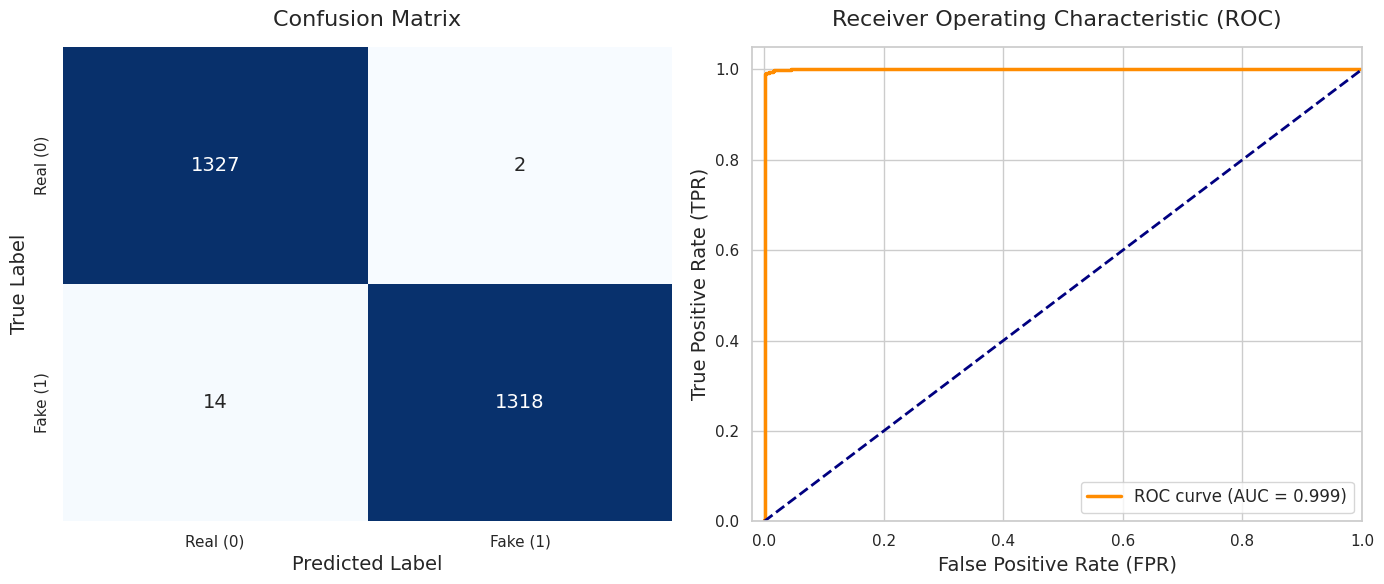

In [ ]:
# ==========================================
# שמירת גרפים לניסוי
# ==========================================

def save_test_plots(test_metrics, experiment_dir):
    labels = test_metrics["labels"]
    preds = test_metrics["preds"]
    probs = test_metrics["probs"]

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        cbar=False,
        xticklabels=["Real (0)", "Fake (1)"],
        yticklabels=["Real (0)", "Fake (1)"]
    )

    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")

    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    plt.tight_layout()

    plot_path = os.path.join(
        experiment_dir,
        "test_plots.png"
    )

    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Plots saved to:", plot_path)


save_test_plots(
    test_metrics,
    EXPERIMENT_DIR
)

In [ ]:
# ==========================================
# דוח מפורט לפי סוג התקפה
# ==========================================

def create_attack_type_report(test_metrics, experiment_dir):
    results_df = pd.DataFrame({
        "path": test_metrics["paths"],
        "attack_type": test_metrics["attack_types"],
        "label": test_metrics["labels"],
        "prediction": test_metrics["preds"],
        "p_fake": test_metrics["probs"]
    })

    results_df["correct"] = results_df["label"] == results_df["prediction"]

    detailed_path = os.path.join(
        experiment_dir,
        "detailed_predictions.csv"
    )

    results_df.to_csv(detailed_path, index=False)

    summary = (
        results_df
        .groupby("attack_type")
        .agg(
            total_files=("label", "count"),
            correct_predictions=("correct", "sum"),
            wrong_predictions=("correct", lambda x: (~x).sum()),
            detected_as_fake=("prediction", lambda x: (x == 1).sum()),
            missed_as_real=("prediction", lambda x: (x == 0).sum()),
            accuracy=("correct", "mean")
        )
        .reset_index()
    )

    summary_path = os.path.join(
        experiment_dir,
        "attack_type_summary.csv"
    )

    summary.to_csv(summary_path, index=False)

    print("Detailed predictions saved to:", detailed_path)
    print("Attack type summary saved to:", summary_path)

    return results_df, summary


detailed_predictions, attack_type_summary = create_attack_type_report(
    test_metrics,
    EXPERIMENT_DIR
)

display(attack_type_summary)

Generating detailed report by attack type (WavLM)...


  0%|          | 0/666 [00:00<?, ?it/s]

,attack_type,total_files,correct_predictions,wrong_predictions,detected_as_fake,missed_as_real,accuracy
0,elevenlabs_fake,222.0,220.0,2.0,220.0,2.0,0.990991
1,neural_vocoder_autoregressive,222.0,206.0,16.0,206.0,16.0,0.927928
2,neural_vocoder_nonautoregressive,222.0,217.0,5.0,217.0,5.0,0.977477
3,real,1329.0,1321.0,8.0,8.0,1321.0,0.993980
4,traditional_vocoder,222.0,217.0,5.0,217.0,5.0,0.977477
5,unknown,222.0,219.0,3.0,219.0,3.0,0.986486
6,waveform_concatenation,222.0,220.0,2.0,220.0,2.0,0.990991



Detailed results saved to /content/wavlm_detailed_results.csv


In [ ]:
# ==========================================
# חיזוי על קובץ אודיו יחיד
# ==========================================

def predict_single_file(
    file_path,
    model,
    device,
    config
):
    model.eval()

    target_sample_rate = config["target_sample_rate"]
    max_duration = config["max_duration"]
    max_length = target_sample_rate * max_duration

    try:
        waveform, sample_rate = torchaudio.load(file_path)
    except Exception as e:
        return {
            "error": f"Could not load audio file: {e}"
        }

    # המרה למונו
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # התאמה ל-16kHz
    if sample_rate != target_sample_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=target_sample_rate
        )
        waveform = resampler(waveform)

    waveform = waveform.squeeze(0)

    # חיתוך / ריפוד כמו ב-validation/test
    length = waveform.shape[0]

    if length > max_length:
        start = (length - max_length) // 2
        waveform = waveform[start:start + max_length]
        attention_mask = torch.ones(max_length, dtype=torch.long)
    else:
        pad_length = max_length - length
        waveform = torch.nn.functional.pad(waveform, (0, pad_length))

        attention_mask = torch.cat([
            torch.ones(length, dtype=torch.long),
            torch.zeros(pad_length, dtype=torch.long)
        ])

    input_values = waveform.unsqueeze(0).to(device)
    attention_mask = attention_mask.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(
            input_values=input_values,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]

    pred_class = torch.argmax(probs).item()

    label = "FAKE" if pred_class == 1 else "REAL"

    return {
        "file_path": file_path,
        "prediction": label,
        "p_real": float(probs[0].item()),
        "p_fake": float(probs[1].item())
    }

In [ ]:
file_to_test = "/content/ElevenLabs_2026-03-09T13_31_32_Titan - Deep, Bold, and Powerful_pvc_sp100_s34_sb75_se44_b_m2.mp3"

result = predict_single_file(
    file_path=file_to_test,
    model=model,
    device=device,
    config=CONFIG
)

print("Prediction:", result["prediction"])
print(f"Real Probability: {result['p_real']:.4f}")
print(f"Fake Probability: {result['p_fake']:.4f}")

{'label': 'REAL', 'p_real': 0.6333343386650085, 'p_fake': 0.36666572093963623}


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
